# CSE 144 Final Project — Transfer Learning (100 classes)

Workflow:

1. **Data** — transforms, `ImageFolder` on `data/train/`, fixed train/val split, DataLoaders
2. **Model** — ImageNet **EfficientNet-B2** + wider head; Phase 1 frozen backbone, Phase 2 full fine-tune with higher LR on the head
3. **Training** — RandAugment, RandomErasing, mixup (phase 2), label smoothing, LR schedules, grad clipping
4. **Submission** — 5-view TTA + `submission.csv` for manual Kaggle upload

In [1]:
# If you are running in a fresh environment, uncomment:
#%pip -q install -r requirements.txt

import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, models, transforms
from tqdm.auto import tqdm

print("torch:", torch.__version__)
if torch.cuda.is_available():
    device = "cuda"
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

DATA_DIR = "./data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")
SAMPLE_SUBMISSION = os.path.join(DATA_DIR, "sample_submission.csv")
CKPT_PATH = "./checkpoints/best_model.pt"
SUBMISSION_OUT = "./submission.csv"

IMG_SIZE = 224
NUM_CLASSES = 100
BATCH_SIZE = 32          # lower to 16 on CPU if you run out of memory
NUM_WORKERS = 0

# --- training recipe (two-phase transfer + strong aug + schedules) ---
PHASE1_EPOCHS = 8
PHASE2_EPOCHS = 45
PHASE1_LR = 3e-3
PHASE2_LR = 1e-4         # backbone in phase 2
PHASE2_HEAD_LR_MULT = 3  # head LR = PHASE2_LR * this

WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
MIXUP_ALPHA = 0.3
GRAD_CLIP_NORM = 1.0
EARLY_STOP_PATIENCE = None  # train full schedule; best checkpoint still saved

# Augmentation
AUGMENT_TRAIN = True
CROP_PADDING = 24
RANDAUG_NUM_OPS = 2
RANDAUG_MAGNITUDE = 9
RANDOM_ERASING_P = 0.2
VAL_FRACTION = 0.05
HEAD_HIDDEN_DIM = 512

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def set_seed(seed: int = 90):
    """Make results as reproducible as possible across runs."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)


set_seed(42)
os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)

torch: 2.12.0+cpu
device: cpu


c:\Users\maria\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

**Train vs validation vs test:** The validation split is fixed (seed 42). We use a **small val split (5%)** so most images stay in training — with ~10 images per class, every sample counts. Val is noisy but useful for checkpointing; Kaggle test is the real score.

In [2]:
# Data pipeline: transforms, ImageFolder, train/val split, DataLoaders

# val / test: resize + normalize only (matches Kaggle eval)
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# train: resize/pad + random crop, flip, RandAugment, RandomErasing
aug_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + CROP_PADDING, IMG_SIZE + CROP_PADDING)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=RANDAUG_NUM_OPS, magnitude=RANDAUG_MAGNITUDE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=RANDOM_ERASING_P, scale=(0.02, 0.15)),
])

train_tf = aug_tf if AUGMENT_TRAIN else eval_tf
val_tf = eval_tf


class ApplyTransform(Dataset):
    """Apply a transform to images from a Subset of ImageFolder (PIL in, tensor out)."""

    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


# ImageFolder: folder name "0".."99" -> label 0..99 (required for Kaggle)
full_train = datasets.ImageFolder(TRAIN_DIR)
assert len(full_train.classes) == NUM_CLASSES, (
    f"Expected {NUM_CLASSES} classes, got {len(full_train.classes)}"
)

# IMPORTANT: ImageFolder sorts class folders alphabetically ("0","1","10",...),
# but the assignment requires numeric label mapping: folder "0" -> label 0, ..., "99" -> 99.
# Remap targets to use the folder name as the integer label.
for i, (path, _old_target) in enumerate(full_train.samples):
    folder = os.path.basename(os.path.dirname(path))
    full_train.samples[i] = (path, int(folder))
full_train.targets = [t for _, t in full_train.samples]
full_train.classes = [str(i) for i in range(NUM_CLASSES)]
full_train.class_to_idx = {str(i): i for i in range(NUM_CLASSES)}

n_val = int(len(full_train) * VAL_FRACTION)
n_train = len(full_train) - n_val
split_gen = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(full_train, [n_train, n_val], generator=split_gen)

train_set = ApplyTransform(train_subset, train_tf)
val_set = ApplyTransform(val_subset, val_tf)

train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

print("classes (first 5):", full_train.classes[:5])
print("train/val:", len(train_set), len(val_set))
print("train augmentation:", AUGMENT_TRAIN)
print("train dir exists:", os.path.isdir(TRAIN_DIR))

classes (first 5): ['0', '1', '2', '3', '4']
train/val: 1026 53
train augmentation: True
train dir exists: True


## Model

In [3]:
from torchvision.models import EfficientNet_B2_Weights

weights = EfficientNet_B2_Weights.IMAGENET1K_V1
model = models.efficientnet_b2(weights=weights)


def set_requires_grad(module, requires_grad: bool):
    for p in module.parameters():
        p.requires_grad = requires_grad


def freeze_efficientnet_features(model):
    """Phase 1: ImageNet features frozen; only classifier trains."""
    set_requires_grad(model.features, False)
    set_requires_grad(model.classifier, True)


def unfreeze_efficientnet_all(model):
    """Phase 2: full fine-tune — all features + head."""
    set_requires_grad(model.features, True)
    set_requires_grad(model.classifier, True)


def build_efficientnet_head(in_features, num_classes, hidden_dim=HEAD_HIDDEN_DIM):
    return nn.Sequential(
        nn.Dropout(p=0.35),
        nn.Linear(in_features, hidden_dim),
        nn.SiLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(hidden_dim, num_classes),
    )


in_features = model.classifier[1].in_features
model.classifier = build_efficientnet_head(in_features, NUM_CLASSES)
model = model.to(device)

total = sum(p.numel() for p in model.parameters())
freeze_efficientnet_features(model)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"EfficientNet-B2 | params: {total:,} | trainable after freeze: {trainable:,}")

EfficientNet-B2 | params: 8,473,702 | trainable after freeze: 772,708


## Training

In [4]:
# --- TRAINING ---
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = None
best_val_acc = 0.0
best_epoch = 0
epochs_without_improvement = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}


def mixup_batch(images, labels, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return images, labels, labels, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1.0 - lam) * images[idx]
    return mixed, labels, labels[idx], lam


def mixup_loss(outputs, y_a, y_b, lam):
    return lam * criterion(outputs, y_a) + (1.0 - lam) * criterion(outputs, y_b)


def train_one_epoch(model, loader, use_mixup=True, scheduler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_mixup and MIXUP_ALPHA > 0:
            images, y_a, y_b, lam = mixup_batch(images, labels)
            outputs = model(images)
            loss = mixup_loss(outputs, y_a, y_b, lam)
            preds = outputs.argmax(dim=1)
            correct += (
                lam * (preds == y_a).float() + (1.0 - lam) * (preds == y_b).float()
            ).sum().item()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item() * images.size(0)
        total += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def save_checkpoint(model, epoch, val_acc):
    torch.save(
        {"model_state_dict": model.state_dict(), "epoch": epoch, "val_acc": val_acc},
        CKPT_PATH,
    )


def run_epochs(
    model,
    max_epochs,
    phase_name,
    lr=None,
    param_groups=None,
    use_mixup=True,
    build_scheduler=None,
):
    global optimizer, best_val_acc, best_epoch, epochs_without_improvement

    if param_groups is not None:
        optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
        lr_msg = f"backbone lr={PHASE2_LR}, head lr={PHASE2_LR * PHASE2_HEAD_LR_MULT}"
    else:
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr,
            weight_decay=WEIGHT_DECAY,
        )
        lr_msg = f"lr={lr}"

    scheduler = build_scheduler(optimizer) if build_scheduler else None

    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n--- {phase_name}: up to {max_epochs} epochs, {lr_msg}, trainable={n_trainable:,} ---")

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, use_mixup=use_mixup, scheduler=scheduler
        )
        val_loss, val_acc = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch}/{max_epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            epochs_without_improvement = 0
            save_checkpoint(model, epoch, val_acc)
            print(f"  -> saved checkpoint (val acc {val_acc:.4f})")
        else:
            epochs_without_improvement += 1

        if EARLY_STOP_PATIENCE and epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"  -> no val improvement for {EARLY_STOP_PATIENCE} epochs; stopping {phase_name}")
            break


# Phase 1: frozen backbone, train head (no mixup)
epochs_without_improvement = 0
freeze_efficientnet_features(model)


def build_phase1_scheduler(opt):
    return torch.optim.lr_scheduler.OneCycleLR(
        opt,
        max_lr=PHASE1_LR,
        total_steps=PHASE1_EPOCHS * len(train_loader),
        pct_start=0.2,
    )


run_epochs(
    model,
    PHASE1_EPOCHS,
    "Phase 1: head warm-up (features frozen)",
    lr=PHASE1_LR,
    use_mixup=False,
    build_scheduler=build_phase1_scheduler,
)

# Phase 2: full fine-tune with mixup, differential LR, cosine decay + warmup
epochs_without_improvement = 0
unfreeze_efficientnet_all(model)
total_steps_phase2 = PHASE2_EPOCHS * len(train_loader)
warmup_steps = 2 * len(train_loader)


def build_phase2_scheduler(opt):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps_phase2 - warmup_steps)
        return 0.5 * (1.0 + np.cos(np.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)


run_epochs(
    model,
    PHASE2_EPOCHS,
    "Phase 2: full fine-tune",
    param_groups=[
        {"params": model.features.parameters(), "lr": PHASE2_LR},
        {"params": model.classifier.parameters(), "lr": PHASE2_LR * PHASE2_HEAD_LR_MULT},
    ],
    use_mixup=True,
    build_scheduler=build_phase2_scheduler,
)

if os.path.isfile(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(
        f"\nLoaded best checkpoint: epoch {ckpt['epoch']} | val acc {ckpt['val_acc']:.4f}"
    )

print(f"Done. Best val acc: {best_val_acc:.4f} at epoch {best_epoch}")


--- Phase 1: head warm-up (features frozen): up to 8 epochs, lr=0.003, trainable=772,708 ---


train:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1/8 | train loss 4.4476 acc 0.0848 | val loss 3.7663 acc 0.2642
  -> saved checkpoint (val acc 0.2642)


Epoch 2/8 | train loss 3.1463 acc 0.2700 | val loss 2.6805 acc 0.5094
  -> saved checkpoint (val acc 0.5094)


Epoch 3/8 | train loss 2.3969 acc 0.4961 | val loss 2.2001 acc 0.5283
  -> saved checkpoint (val acc 0.5283)


...

Epoch 23/45 | train loss 1.5995 acc 0.8542 | val loss 1.7222 acc 0.6981


Epoch 24/45 | train loss 1.6676 acc 0.8325 | val loss 1.7279 acc 0.6792


Epoch 25/45 | train loss 1.6291 acc 0.8477 | val loss 1.7909 acc 0.7170


Epoch 26/45 | train loss 1.8158 acc 0.7963 | val loss 1.7823 acc 0.6604


KeyboardInterrupt: 

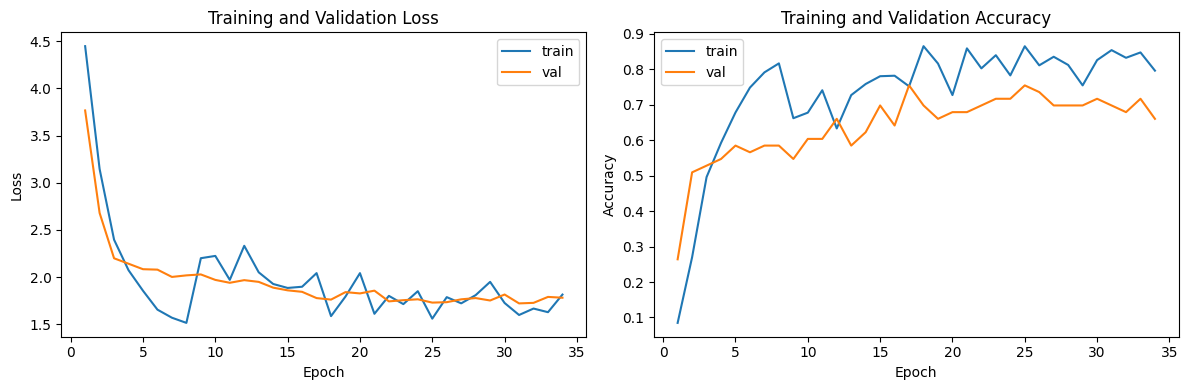

In [5]:
# Plot training curves (HW2 Q3.4)

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="train")
axes[1].plot(epochs_range, history["val_acc"], label="val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training and Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Submission

After training, **run the cell below** to create `submission.csv` with **5-view test-time augmentation** (columns `ID`, `Label`). 

In [6]:
# Run this cell after training. Writes submission.csv for manual Kaggle upload.


class TestImageDataset(Dataset):
    def __init__(self, test_dir, image_ids, transform=None):
        self.test_dir = test_dir
        self.image_ids = list(image_ids)
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        fname = self.image_ids[idx]
        path = os.path.join(self.test_dir, fname)
        image = Image.open(path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, fname


tta_tf_list = [
    val_tf,
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE + CROP_PADDING, IMG_SIZE + CROP_PADDING)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE + CROP_PADDING, IMG_SIZE + CROP_PADDING)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
]


@torch.no_grad()
def predict_with_tta(model, image_ids):
    model.eval()
    prob_sums = {}

    for tf in tta_tf_list:
        loader = DataLoader(
            TestImageDataset(TEST_DIR, image_ids, transform=tf),
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
        )
        for images, fnames in tqdm(loader, leave=False, desc="tta view"):
            probs = torch.softmax(model(images.to(device)), dim=1).cpu().numpy()
            for fname, prob in zip(fnames, probs):
                if fname not in prob_sums:
                    prob_sums[fname] = np.zeros(NUM_CLASSES, dtype=np.float64)
                prob_sums[fname] += prob

    return {fname: int(np.argmax(prob)) for fname, prob in prob_sums.items()}


submission_df = pd.read_csv(SAMPLE_SUBMISSION)
sample_ids = set(submission_df["ID"].tolist())
extra_ids = sorted(
    [
        f
        for f in os.listdir(TEST_DIR)
        if f.endswith(".jpg") and f not in sample_ids
    ],
    key=lambda x: int(x.split(".")[0]),
)
all_test_ids = submission_df["ID"].tolist() + extra_ids
print(f"Test images: {len(all_test_ids)} ({len(submission_df)} sample + {len(extra_ids)} extra)")

if not os.path.isfile(CKPT_PATH):
    raise FileNotFoundError(f"No checkpoint at {CKPT_PATH}. Run the training cell first.")

checkpoint = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Checkpoint epoch {checkpoint.get('epoch', '?')} | val acc {checkpoint.get('val_acc', 0):.4f}")

print("Running 5-view TTA inference ...")
predictions = predict_with_tta(model, all_test_ids)

out_df = pd.DataFrame({"ID": all_test_ids, "Label": [predictions[i] for i in all_test_ids]})
assert set(out_df["Label"]) <= set(range(NUM_CLASSES))

out_df.to_csv(SUBMISSION_OUT, index=False)
print(f"Wrote {SUBMISSION_OUT} ({len(out_df)} rows)")
print("Upload this file on Kaggle.")
print(out_df.head())

Test images: 1036 (1000 sample + 36 extra)
Checkpoint epoch 9 | val acc 0.7547
Running 5-view TTA inference ...


Wrote ./submission.csv (1036 rows)
Upload this file on Kaggle.
      ID  Label
0  0.jpg     66
1  1.jpg     43
2  2.jpg     38
3  3.jpg     60
4  4.jpg     42
